# Data loading

In [1]:
from recommender_system.data.load import load_data
from recommender_system.data.transform import transform_reviews

df = load_data('../data/australian_user_reviews.json.gz')
reviews = transform_reviews(df)

reviews = reviews.astype({'recommend': 'int'})
reviews.head()

,user_id,posted,item_id,recommend
0,76561197970982479,"Posted November 5, 2011.",1250,1
1,76561197970982479,"Posted July 15, 2011.",22200,1
2,76561197970982479,"Posted April 21, 2011.",43110,1
3,js41637,"Posted June 24, 2014.",251610,1
4,js41637,"Posted September 8, 2013.",227300,1


Construct sparse matrix

In [ ]:
from recommender_system.features.interactions import df2interact_mat
from sklearn.metrics.pairwise import cosine_similarity


interactions, item_to_idx = df2interact_mat(reviews, 'user_id', 'item_id', 'recommend')

similarities = cosine_similarity(interactions.T, dense_output=False) #Transpose leads to item-item similarity matrix
similarities.shape

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [ ]:
import pandas as pd

games = load_data("../data/steam_games.json.gz")
games = games.rename({'id': 'item_id'}, axis=1)
item_ids = pd.Index(games["item_id"].drop_duplicates())

for item_id in ["440", "730", "224260"]:
    name = games.loc[games["item_id"] == item_id, "app_name"].values[0]
    idx = item_to_idx[item_id]
    similar_items = similarities[idx].argsort()[::-1][1:6]  # Get top 5 similar items, excluding itself
    print(f"Top 5 items similar to {name} ({item_id}):")
    for sim_idx in similar_items:
        sim_item_id = item_ids[sim_idx]
        sim_score = similarities[idx, sim_idx]
        sim_name = games.loc[games["item_id"] == sim_item_id, "app_name"].values[0]
        print(f"Name: {sim_name}, Score: {sim_score:.4f}")
    print()

Top 5 items similar to Team Fortress 2 (440):
Name: Garry's Mod, Score: 0.1262
Name: Counter-Strike: Global Offensive, Score: 0.1153
Name: Left 4 Dead 2, Score: 0.1022
Name: Unturned, Score: 0.0859
Name: Dota 2, Score: 0.0813

Top 5 items similar to Counter-Strike: Global Offensive (730):
Name: Team Fortress 2, Score: 0.1153
Name: Garry's Mod, Score: 0.1066
Name: PAYDAY 2, Score: 0.0863
Name: Dota 2, Score: 0.0835
Name: Rust, Score: 0.0831

Top 5 items similar to No More Room in Hell (224260):
Name: Simply Chess, Score: 0.0910
Name: PAYDAY 2: The Point Break Heists, Score: 0.0910
Name: Estranged: Act I, Score: 0.0638
Name: Team Fortress 2, Score: 0.0634
Name: Zombie Panic! Source, Score: 0.0619



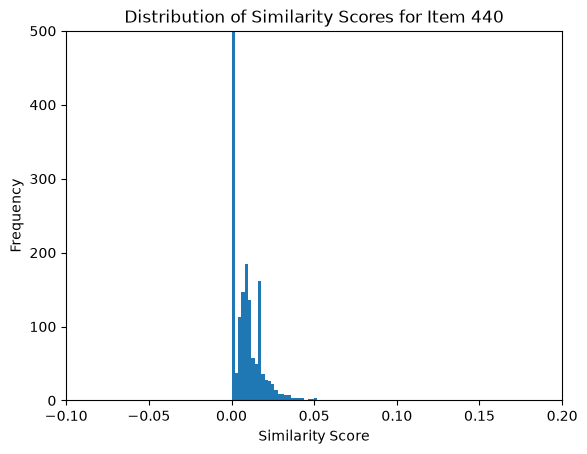

In [36]:
#Generate histogram of similarity scores for a specific item
import matplotlib.pyplot as plt
plt.hist(similarities[item_to_idx["440"]].flatten(), bins=500)
plt.xlabel("Similarity Score")
plt.ylabel("Frequency")
plt.title("Distribution of Similarity Scores for Item 440")
plt.xlim(-0.1, 0.2)
plt.ylim(0, 500)
plt.show()